Логистическая регрессия: Accuracy = 0.755
Дерево решений: Accuracy = 0.706


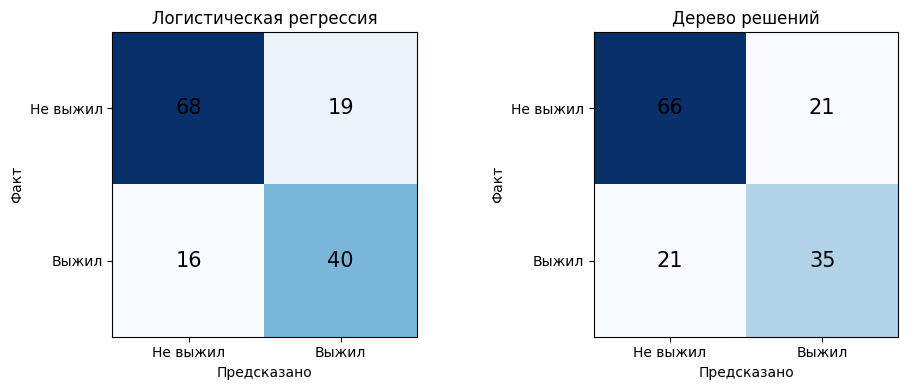

In [1]:
# Лабораторная работа №3 - Титаник
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Загрузка и подготовка данных
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].dropna()
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Разделение
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Модели
lr = LogisticRegression()
dt = DecisionTreeClassifier()
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

# Вывод метрик
print(f'Логистическая регрессия: Accuracy = {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'Дерево решений: Accuracy = {accuracy_score(y_test, y_pred_dt):.3f}')

# Графики
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Матрица ошибок для Логистической регрессии
cm_lr = confusion_matrix(y_test, y_pred_lr)
axes[0].imshow(cm_lr, cmap='Blues', interpolation='nearest')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_lr[i, j]), ha='center', va='center', fontsize=15)
axes[0].set_title('Логистическая регрессия')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Факт')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Не выжил', 'Выжил'])
axes[0].set_yticklabels(['Не выжил', 'Выжил'])

# Матрица ошибок для Дерева решений
cm_dt = confusion_matrix(y_test, y_pred_dt)
axes[1].imshow(cm_dt, cmap='Blues', interpolation='nearest')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_dt[i, j]), ha='center', va='center', fontsize=15)
axes[1].set_title('Дерево решений')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Факт')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Не выжил', 'Выжил'])
axes[1].set_yticklabels(['Не выжил', 'Выжил'])

plt.tight_layout()
plt.show()
